In [6]:
# downloads dependies 
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [7]:
# importig dataset 
df = pd.read_csv("Downloads/retail_sales_dataset.csv")

In [8]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [10]:
# checking missing data in dataset 
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
# datatype checking 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [32]:
# fixing date column data type 
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
# converting total amount dataset into float data set 
df['Total Amount'] = df['Total Amount'].astype(float)

# Create RFM Metrics

In [13]:
# calculating how many days have passed since a customer last bought something
import datetime
reference_date = df['Date'].max() + datetime.timedelta(days=1)

In [14]:
# Recency, Frequency, Monetary
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'Transaction ID': 'count',
    'Total Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,CUST001,39,1,150.0
1,CUST002,309,1,1000.0
2,CUST003,354,1,30.0
3,CUST004,226,1,500.0
4,CUST005,241,1,100.0


In [15]:
# Create 5 equal-sized buckets for Recency. 
# Note: Higher score (5) means fewer days since last visit (Better).
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [16]:
# Create 5 equal-sized buckets for frequency. 
# Note: Higher score (5) means fewer days since last visit (Better).
rfm['F_score'] = rfm['Frequency'].rank(method='first')
rfm['F_score'] = pd.qcut(rfm['F_score'], 5, labels=[1,2,3,4,5])

In [17]:
# Create 5 equal-sized buckets for amount of money did each coustomer pay . 
# Note: Higher score (5) means fewer days since last visit (Better).
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [19]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,CUST001,39,1,150.0,5,1,3,513
1,CUST002,309,1,1000.0,1,1,4,114
2,CUST003,354,1,30.0,1,1,1,111
3,CUST004,226,1,500.0,2,1,4,214
4,CUST005,241,1,100.0,2,1,2,212


In [20]:
# creating customer Category 
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Best Customers'
    elif int(row['F_score']) >= 4:
        return 'Loyal Customers'
    elif int(row['R_score']) <= 2:
        return 'At Risk'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,CUST001,39,1,150.0,5,1,3,513,Regular Customers
1,CUST002,309,1,1000.0,1,1,4,114,At Risk
2,CUST003,354,1,30.0,1,1,1,111,At Risk
3,CUST004,226,1,500.0,2,1,4,214,At Risk
4,CUST005,241,1,100.0,2,1,2,212,At Risk


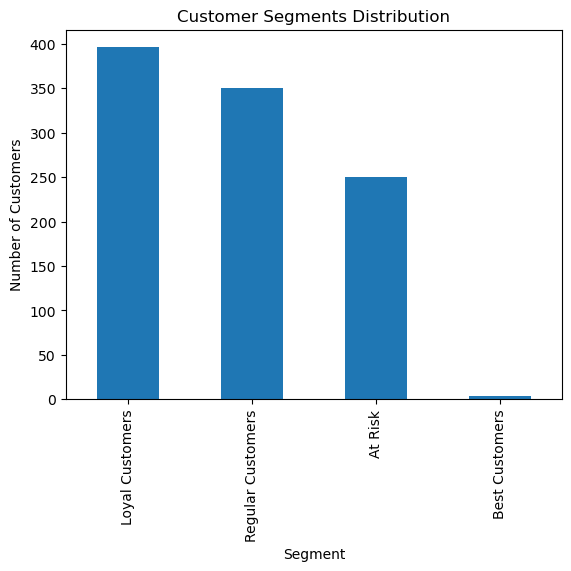

In [21]:
# visulaizing the customer segements distribution 
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
# analyzing according to gender 
df.groupby('Gender')['Total Amount'].sum()

Gender
Female    232840.0
Male      223160.0
Name: Total Amount, dtype: float64

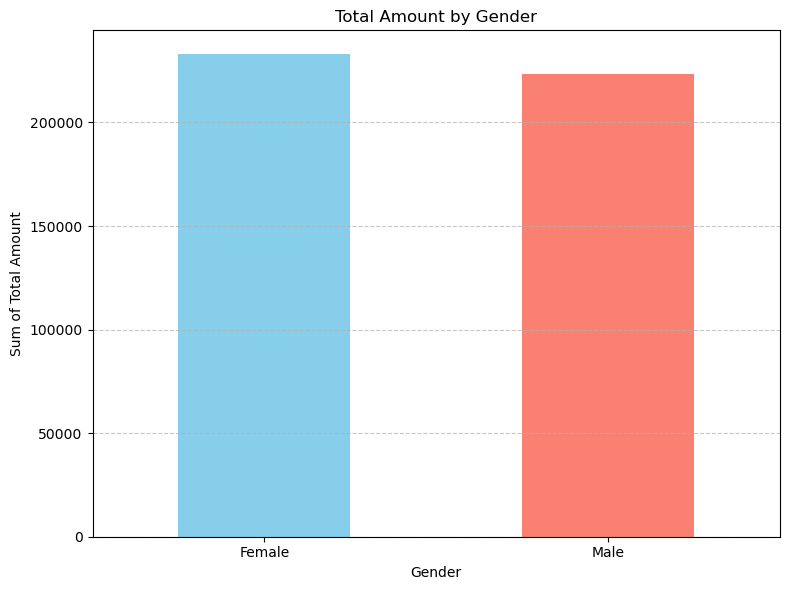

In [27]:
# Grouping and summing the data
gender_sums = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

# Creating the bar chart
plt.figure(figsize=(8, 6))
gender_sums.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])

# Adding labels and title
plt.title('Total Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Sum of Total Amount')
plt.xticks(rotation=0)  # Keeps the gender labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [24]:
# analysing using age groups 
df['Age_Group'] = pd.cut(df['Age'], bins=[18,25,35,50,70], labels=['18-25','26-35','36-50','50+'])

df.groupby('Age_Group')['Total Amount'].sum()

Age_Group
18-25     73335.0
26-35     98480.0
36-50    139660.0
50+      133310.0
Name: Total Amount, dtype: float64

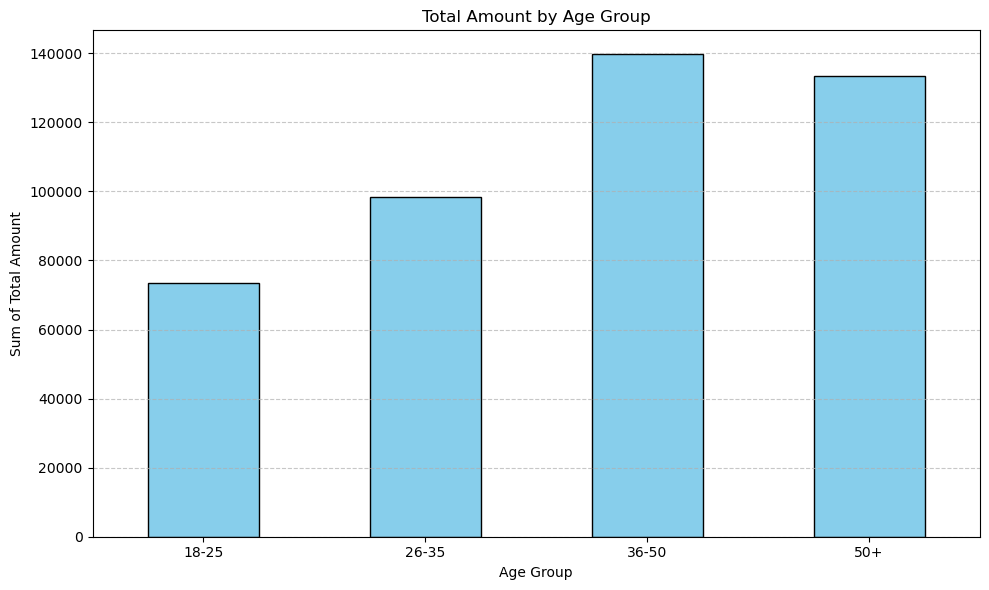

In [26]:
# 1. Define bins and group the data
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 70], labels=['18-25', '26-35', '36-50', '50+'])
age_group_sums = df.groupby('Age_Group')['Total Amount'].sum()

# 2. Creating the bar chart
plt.figure(figsize=(10, 6))
age_group_sums.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Adding labels, title, and grid
plt.title('Total Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sum of Total Amount')
plt.xticks(rotation=0)  # Keep labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Display the plot
plt.tight_layout()
plt.show()

In [28]:
# analyzing using product category 
df.groupby('Product Category')['Total Amount'].sum()

Product Category
Beauty         143515.0
Clothing       155580.0
Electronics    156905.0
Name: Total Amount, dtype: float64

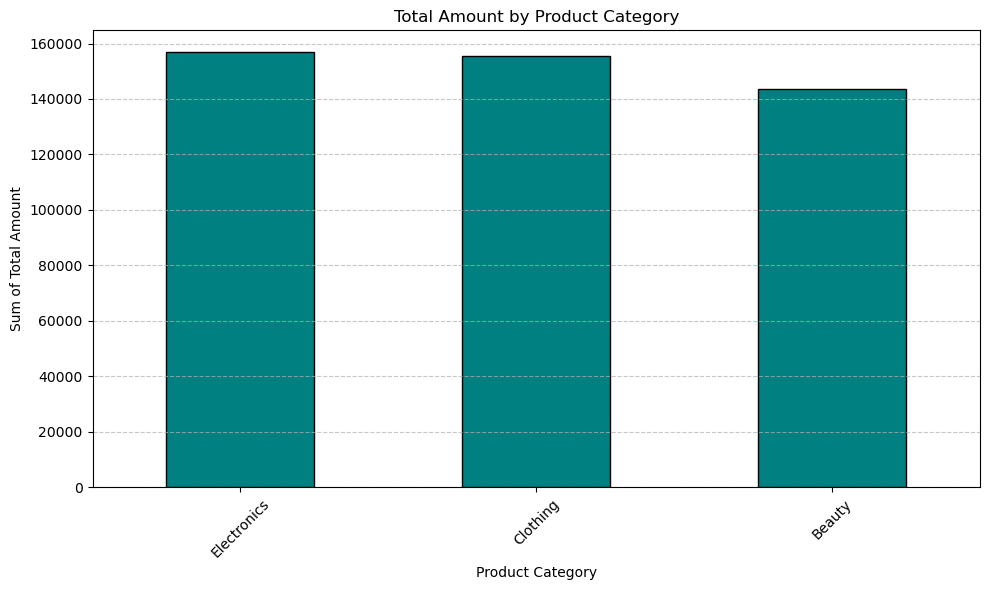

In [29]:
import matplotlib.pyplot as plt

# 1. Grouping and summing the data
# We sort by value to make the chart easier to read
category_sums = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# 2. Creating the bar chart
plt.figure(figsize=(10, 6))
category_sums.plot(kind='bar', color='teal', edgecolor='black')

# 3. Adding labels, title, and grid
plt.title('Total Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sum of Total Amount')
plt.xticks(rotation=45) # Rotated for better readability if labels are long
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Display the plot
plt.tight_layout()
plt.show()

In [30]:
# exporting output file 
rfm.to_csv("rfm_output.csv", index=False)

In [31]:
from IPython.display import FileLink

# This creates a blue clickable link in your notebook
FileLink("rfm_output.csv")

C:\Users\HP\rfm_output.csv